# Runtime scaling of SciPy L-BFGS-B

This notebook investigates a possible runtime-scaling issue in `scipy.optimize.minimize(method="L-BFGS-B")`.

The question is deliberately about wall-clock overhead, not which method reaches the smallest objective value.

## Reproduction protocol

All solvers receive an analytic gradient, use L-BFGS memory `m=10`, run without callbacks, and have convergence tolerances disabled as far as their public interfaces allow. 

In [4]:
import os
import platform
import sys
import time
from dataclasses import asdict, dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import minimize

from qnlab.parameter import LineParameter, NTRQNParameter
from qnlab.problem.base import BaseProblem
from qnlab.solver.qn_line import qn_line
from qnlab.solver.qn_ntrqn import qn_ntrqn
from qnlab.util.method import Method
from qnlab.problem.ill_quadratic import IllQuadraticProblem

ENVIRONMENT = {
    "python": sys.version.replace("\n", " "),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "platform": platform.platform(),
    "processor": platform.processor() or "not reported",
    "cpu_count": os.cpu_count(),
}
pd.Series(ENVIRONMENT, name="value").to_frame()

,value
python,"3.12.11 (main, Sep 18 2025, 19:45:51) [MSC v.1..."
numpy,2.2.6
scipy,1.16.1
platform,Windows-11-10.0.26200-SP0
processor,"Intel64 Family 6 Model 186 Stepping 2, Genuine..."
cpu_count,16


## Problem definition

We used the following two test problems to investigate the issue.

### Problem 1: A smooth zero-chain problem

The first one is the famous "zero-chain" problem. For dimension $n$, define

$$
f(x)=\frac12 x_1^2-x_1+\frac12\sum_{i=1}^{n-1}(x_i-x_{i+1})^2.
$$

This is a strictly convex, ill-conditioned quadratic with minimizer $x^*=(1,\ldots,1)$.
Taking `dimension > max_iterations` prevents the algorithm from simply exhausting the chain before the 10,000-iteration measurement.
Both the function and gradient below cost $\mathcal{O}(n)$ and allocate only a few vectors.


In [5]:
class ZeroChainQuadratic(BaseProblem):
    def __init__(self, n: int):
        super().__init__(name="ZeroChainQuadratic", n=n, x0=np.zeros(n))
        self.x_opt = np.ones(n)

    def _f(self, x: np.ndarray) -> np.float64:
        differences = x[:-1] - x[1:]
        return np.float64(0.5 * x[0] ** 2 - x[0] + 0.5 * differences @ differences)

    def _g(self, x: np.ndarray) -> np.ndarray:
        differences = x[:-1] - x[1:]
        gradient = np.zeros_like(x)
        gradient[0] = x[0] - 1.0
        gradient[:-1] += differences
        gradient[1:] -= differences
        return gradient


# Sanity checks for the formula and zero-chain structure.
_problem = ZeroChainQuadratic(8)
assert np.isclose(_problem.f(_problem.x_opt, count=False), -0.5)
assert np.allclose(_problem.g(_problem.x_opt, count=False), 0.0)
assert np.array_equal(np.flatnonzero(_problem.g(_problem.x0, count=False)), [0])

## Problem 2: A diagonal quadratic problem

The second problem is a diagonal quadratic, which is close to `script/computation_time.py`.

The diagonal quadratic is

$$
f(x)=\frac12 x^\top \operatorname{diag}(1,\ldots,n)x.
$$

The initial point is $x_{\mathrm{init}}=(1,\ldots,1)$, and the minimizer is $x^*=(0,\ldots,0)$.


In [6]:
# Sanity checks for the formula.
_problem = IllQuadraticProblem(8)
assert np.isclose(_problem.f(_problem.x_opt, count=False), 0.0)
assert np.allclose(_problem.g(_problem.x_opt, count=False), 0.0)
assert np.array_equal(_problem.g(_problem.x0, count=False), list(range(1, 8 + 1)))

## Benchmark implementation

The iteration cap controls termination by setting `ftol=gtol=0`.

In [10]:
from collections.abc import Callable

MEMORY = 10
ITERATION_DIMENSION = 12_00  # Must exceed max(ITERATION_BUDGETS).
ITERATION_BUDGETS = np.array([100, 300, 500, 700, 900, 1100])
REPEATS = 3

DIMENSION_ITERATIONS = 500
DIMENSIONS = np.array([500, 1000, 2000, 5000])
DIMENSION_REPEATS = 3

assert ITERATION_DIMENSION > ITERATION_BUDGETS.max()
assert DIMENSIONS.min() > DIMENSION_ITERATIONS
SOLVERS = ("SciPy L-BFGS-B", "qnlab qn_line", "qnlab qn_ntrqn")

AssertionError: 

In [11]:
@dataclass
class TimingResult:
    solver: str
    dimension: int
    requested_iterations: int
    repeat: int
    elapsed_seconds: float
    iterations: int | None
    function_calls: int
    gradient_calls: int
    final_objective: float
    exit_status: str


def run_once(
    solver: str,
    dimension: int,
    max_iterations: int,
    repeat: int,
    memory: int = MEMORY,
    problem_factory: Callable[[int], BaseProblem] = ZeroChainQuadratic,
) -> TimingResult:
    problem = problem_factory(dimension)
    evaluation_limit = 50 * max_iterations + 100
    qnlab_options: dict[str, np.float64 | int] = {
        "m": memory,
        "max_iterations": max_iterations,
        "max_evaluations": evaluation_limit,
        "past": 0,
        "ftol": np.float64(0),
        "gtol": np.float64(0),
    }

    start = time.perf_counter()
    if solver == "SciPy L-BFGS-B":
        result = minimize(
            problem.f,
            problem.x0.copy(),
            jac=problem.g,
            method="L-BFGS-B",
            bounds=None,
            callback=None,
            options={
                "maxcor": memory,
                "maxiter": max_iterations,
                "maxfun": evaluation_limit,
                "ftol": 0.0,
                "gtol": 0.0,
                "maxls": 40,
            },
        )
        elapsed = time.perf_counter() - start
        iterations = int(result.nit)
        final_objective = float(result.fun)
        exit_status = str(result.message)
    elif solver == "qnlab qn_line":
        method = Method(base="Line", store="raw", secant="raw", update="bfgs")
        parameter = LineParameter(dimension, qnlab_options)
        code, final_objective, _ = qn_line(problem, parameter, method, callback=None)
        elapsed = time.perf_counter() - start
        iterations = max_iterations if "MAXIMUMITERATION" in str(code) else None
        exit_status = str(code)
    elif solver == "qnlab qn_ntrqn":
        method = Method(base="NTRQN", store="cautious", secant="damped", update="bfgs")
        parameter = NTRQNParameter(dimension, qnlab_options)
        code, final_objective, _ = qn_ntrqn(
            problem, parameter, method, callback=None, verbose=False
        )
        elapsed = time.perf_counter() - start
        iterations = max_iterations if "MAXIMUMITERATION" in str(code) else None
        exit_status = str(code)
    else:
        raise ValueError(f"Unknown solver: {solver}")

    return TimingResult(
        solver=solver,
        dimension=dimension,
        requested_iterations=max_iterations,
        repeat=repeat,
        elapsed_seconds=elapsed,
        iterations=iterations,
        function_calls=problem.call_f,
        gradient_calls=problem.call_g,
        final_objective=float(final_objective),
        exit_status=exit_status,
    )


def benchmark(
    cases: list[tuple[int, int]],
    repeats: int,
    problem_factory: Callable[[int], BaseProblem] = ZeroChainQuadratic,
    memory: int = MEMORY,
) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    # Untimed warm-up initializes imports and native code paths.
    for solver in SOLVERS:
        run_once(
            solver,
            dimension=600,
            max_iterations=5,
            repeat=-1,
            memory=memory,
            problem_factory=problem_factory,
        )

    for repeat in range(repeats):
        ordered_solvers = (
            SOLVERS[repeat % len(SOLVERS) :] + SOLVERS[: repeat % len(SOLVERS)]
        )
        for dimension, iterations in cases:
            for solver in ordered_solvers:
                measurement = run_once(
                    solver,
                    dimension,
                    iterations,
                    repeat,
                    memory=memory,
                    problem_factory=problem_factory,
                )
                rows.append(asdict(measurement))
                print(
                    f"repeat={repeat + 1}/{repeats}, n={dimension}, k={iterations}, "
                    f"m={memory}, "
                    f"{solver}: {measurement.elapsed_seconds:.3f} s"
                )
    return pd.DataFrame(rows)


def summarize(results: pd.DataFrame, *keys: str) -> pd.DataFrame:
    return results.groupby(["solver", *keys], as_index=False).agg(
        median_seconds=("elapsed_seconds", "median"),
        min_seconds=("elapsed_seconds", "min"),
        max_seconds=("elapsed_seconds", "max"),
        median_function_calls=("function_calls", "median"),
        median_gradient_calls=("gradient_calls", "median"),
        median_objective=("final_objective", "median"),
    )


def show_dimension_scaling(results: pd.DataFrame, title: str) -> pd.DataFrame:
    summary = summarize(results, "dimension")
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for solver, group in summary.groupby("solver"):
        ax.loglog(group["dimension"], group["median_seconds"], "o-", label=solver)
    ax.set(xlabel="Dimension n", ylabel="Median elapsed time [s]", title=title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    display(summary)
    plt.show()
    return summary

## Experiment 1: elapsed time versus iteration budget

In [12]:
iteration_cases = [(ITERATION_DIMENSION, int(k)) for k in ITERATION_BUDGETS]
iteration_results = benchmark(iteration_cases, repeats=REPEATS)

repeat=1/3, n=1200, k=100, m=10, SciPy L-BFGS-B: 0.044 s
repeat=1/3, n=1200, k=100, m=10, qnlab qn_line: 0.021 s
repeat=1/3, n=1200, k=100, m=10, qnlab qn_ntrqn: 0.023 s
repeat=1/3, n=1200, k=300, m=10, SciPy L-BFGS-B: 0.081 s
repeat=1/3, n=1200, k=300, m=10, qnlab qn_line: 0.071 s
repeat=1/3, n=1200, k=300, m=10, qnlab qn_ntrqn: 0.081 s
repeat=1/3, n=1200, k=500, m=10, SciPy L-BFGS-B: 0.092 s
repeat=1/3, n=1200, k=500, m=10, qnlab qn_line: 0.129 s
repeat=1/3, n=1200, k=500, m=10, qnlab qn_ntrqn: 0.157 s
repeat=1/3, n=1200, k=700, m=10, SciPy L-BFGS-B: 0.141 s
repeat=1/3, n=1200, k=700, m=10, qnlab qn_line: 0.205 s
repeat=1/3, n=1200, k=700, m=10, qnlab qn_ntrqn: 0.216 s
repeat=1/3, n=1200, k=900, m=10, SciPy L-BFGS-B: 0.210 s
repeat=1/3, n=1200, k=900, m=10, qnlab qn_line: 0.221 s
repeat=1/3, n=1200, k=900, m=10, qnlab qn_ntrqn: 0.276 s
repeat=1/3, n=1200, k=1100, m=10, SciPy L-BFGS-B: 0.296 s
repeat=1/3, n=1200, k=1100, m=10, qnlab qn_line: 0.356 s
repeat=1/3, n=1200, k=1100, m=10, q

,solver,requested_iterations,median_seconds,min_seconds,max_seconds,median_function_calls,median_gradient_calls,median_objective
0,SciPy L-BFGS-B,100,0.026817,0.020760,0.044001,103.0,103.0,-0.494569
1,SciPy L-BFGS-B,300,0.071993,0.054324,0.080558,308.0,308.0,-0.498168
2,SciPy L-BFGS-B,500,0.123186,0.091952,0.131777,511.0,511.0,-0.498896
3,SciPy L-BFGS-B,700,0.197507,0.140668,0.240637,716.0,716.0,-0.499213
4,SciPy L-BFGS-B,900,0.210109,0.159214,0.235007,920.0,920.0,-0.499379
5,SciPy L-BFGS-B,1100,0.293678,0.233294,0.296302,1122.0,1122.0,-0.499493
6,qnlab qn_line,100,0.021027,0.020895,0.022927,103.0,103.0,-0.494598
7,qnlab qn_line,300,0.070568,0.061970,0.073361,308.0,308.0,-0.498156
8,qnlab qn_line,500,0.129454,0.125805,0.129703,516.0,516.0,-0.498893
9,qnlab qn_line,700,0.198793,0.195713,0.204996,723.0,723.0,-0.499206


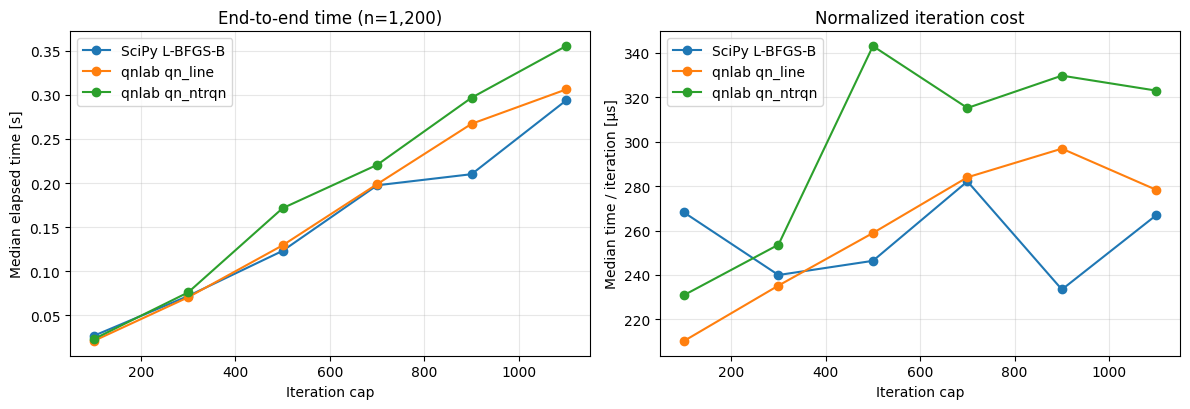

In [13]:
iteration_summary = summarize(iteration_results, "requested_iterations")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for solver, group in iteration_summary.groupby("solver"):
    axes[0].plot(
        group["requested_iterations"], group["median_seconds"], "o-", label=solver
    )
    axes[1].plot(
        group["requested_iterations"],
        1e6 * group["median_seconds"] / group["requested_iterations"],
        "o-",
        label=solver,
    )
axes[0].set(
    xlabel="Iteration cap",
    ylabel="Median elapsed time [s]",
    title=f"End-to-end time (n={ITERATION_DIMENSION:,})",
)
axes[1].set(
    xlabel="Iteration cap",
    ylabel="Median time / iteration [µs]",
    title="Normalized iteration cost",
)
for ax in axes:
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.tight_layout()
display(iteration_summary)

## Experiment 2: elapsed time versus dimension

repeat=1/3, n=500, k=500, m=10, SciPy L-BFGS-B: 0.116 s
repeat=1/3, n=500, k=500, m=10, qnlab qn_line: 0.084 s
repeat=1/3, n=500, k=500, m=10, qnlab qn_ntrqn: 0.092 s
repeat=1/3, n=1000, k=500, m=10, SciPy L-BFGS-B: 0.113 s
repeat=1/3, n=1000, k=500, m=10, qnlab qn_line: 0.095 s
repeat=1/3, n=1000, k=500, m=10, qnlab qn_ntrqn: 0.119 s
repeat=1/3, n=2000, k=500, m=10, SciPy L-BFGS-B: 0.162 s
repeat=1/3, n=2000, k=500, m=10, qnlab qn_line: 0.146 s
repeat=1/3, n=2000, k=500, m=10, qnlab qn_ntrqn: 0.212 s
repeat=1/3, n=5000, k=500, m=10, SciPy L-BFGS-B: 0.293 s
repeat=1/3, n=5000, k=500, m=10, qnlab qn_line: 0.352 s
repeat=1/3, n=5000, k=500, m=10, qnlab qn_ntrqn: 0.319 s
repeat=2/3, n=500, k=500, m=10, qnlab qn_line: 0.104 s
repeat=2/3, n=500, k=500, m=10, qnlab qn_ntrqn: 0.150 s
repeat=2/3, n=500, k=500, m=10, SciPy L-BFGS-B: 0.076 s
repeat=2/3, n=1000, k=500, m=10, qnlab qn_line: 0.124 s
repeat=2/3, n=1000, k=500, m=10, qnlab qn_ntrqn: 0.162 s
repeat=2/3, n=1000, k=500, m=10, SciPy L-BF

,solver,dimension,median_seconds,min_seconds,max_seconds,median_function_calls,median_gradient_calls,median_objective
0,SciPy L-BFGS-B,500,0.116218,0.075618,0.124760,511.0,511.0,-0.498896
1,SciPy L-BFGS-B,1000,0.105162,0.102181,0.112534,511.0,511.0,-0.498896
2,SciPy L-BFGS-B,2000,0.156328,0.144989,0.162061,511.0,511.0,-0.498896
3,SciPy L-BFGS-B,5000,0.299445,0.293477,0.329856,511.0,511.0,-0.498896
4,qnlab qn_line,500,0.100104,0.083808,0.104409,516.0,516.0,-0.498893
5,qnlab qn_line,1000,0.123964,0.095500,0.158388,516.0,516.0,-0.498893
6,qnlab qn_line,2000,0.171786,0.146479,0.187287,516.0,516.0,-0.498893
7,qnlab qn_line,5000,0.368841,0.351980,0.428228,516.0,516.0,-0.498893
8,qnlab qn_ntrqn,500,0.119556,0.091518,0.149514,516.0,501.0,-0.498898
9,qnlab qn_ntrqn,1000,0.144536,0.119352,0.161787,516.0,501.0,-0.498898


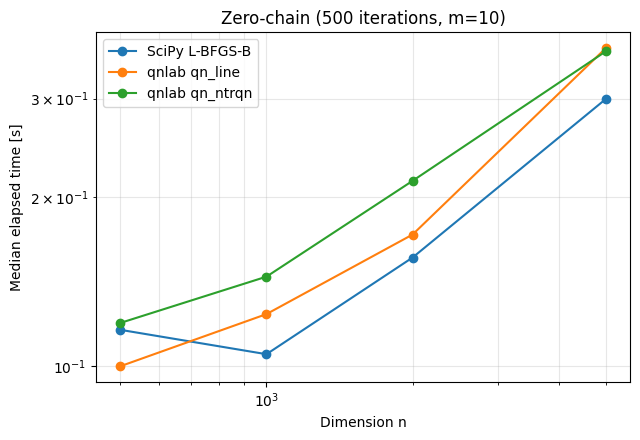

In [14]:
dimension_cases = [(int(n), DIMENSION_ITERATIONS) for n in DIMENSIONS]
dimension_results = benchmark(dimension_cases, repeats=DIMENSION_REPEATS)
dimension_summary = show_dimension_scaling(
    dimension_results,
    f"Zero-chain ({DIMENSION_ITERATIONS} iterations, m={MEMORY})",
)

## Experiment 3: diagonal quadratic at large dimension

In [16]:
ILL_QUADRATIC_ITERATIONS = 100
ILL_QUADRATIC_DIMENSIONS = np.array([100, 300, 1000, 3000, 10000, 30000])
ILL_QUADRATIC_REPEATS = 10  # Use 3 for a quick run; the original script uses 100.

ill_quadratic_cases = [
    (int(n), ILL_QUADRATIC_ITERATIONS) for n in ILL_QUADRATIC_DIMENSIONS
]
ill_quadratic_results = benchmark(
    ill_quadratic_cases,
    repeats=ILL_QUADRATIC_REPEATS,
    problem_factory=IllQuadraticProblem,
)

repeat=1/10, n=100, k=100, m=10, SciPy L-BFGS-B: 0.027 s
repeat=1/10, n=100, k=100, m=10, qnlab qn_line: 0.015 s
repeat=1/10, n=100, k=100, m=10, qnlab qn_ntrqn: 0.019 s
repeat=1/10, n=300, k=100, m=10, SciPy L-BFGS-B: 0.014 s
repeat=1/10, n=300, k=100, m=10, qnlab qn_line: 0.013 s
repeat=1/10, n=300, k=100, m=10, qnlab qn_ntrqn: 0.013 s
repeat=1/10, n=1000, k=100, m=10, SciPy L-BFGS-B: 0.040 s
repeat=1/10, n=1000, k=100, m=10, qnlab qn_line: 0.024 s
repeat=1/10, n=1000, k=100, m=10, qnlab qn_ntrqn: 0.026 s
repeat=1/10, n=3000, k=100, m=10, SciPy L-BFGS-B: 0.042 s
repeat=1/10, n=3000, k=100, m=10, qnlab qn_line: 0.035 s
repeat=1/10, n=3000, k=100, m=10, qnlab qn_ntrqn: 0.034 s
repeat=1/10, n=10000, k=100, m=10, SciPy L-BFGS-B: 0.070 s
repeat=1/10, n=10000, k=100, m=10, qnlab qn_line: 0.159 s
repeat=1/10, n=10000, k=100, m=10, qnlab qn_ntrqn: 0.165 s
repeat=1/10, n=30000, k=100, m=10, SciPy L-BFGS-B: 0.510 s
repeat=1/10, n=30000, k=100, m=10, qnlab qn_line: 1.049 s
repeat=1/10, n=30000,

C:\Users\hirok\AppData\Local\Temp\ipykernel_26212\716064774.py:17: RankWarning: Polyfit may be poorly conditioned
  large_slope = np.polyfit(
C:\Users\hirok\AppData\Local\Temp\ipykernel_26212\716064774.py:17: RankWarning: Polyfit may be poorly conditioned
  large_slope = np.polyfit(
C:\Users\hirok\AppData\Local\Temp\ipykernel_26212\716064774.py:17: RankWarning: Polyfit may be poorly conditioned
  large_slope = np.polyfit(


,solver,dimension,median_seconds,min_seconds,max_seconds,median_function_calls,median_gradient_calls,median_objective,ratio_to_qn_line
0,SciPy L-BFGS-B,100,0.011755,0.010161,0.027035,107.0,107.0,2.587600e-18,1.079657
1,SciPy L-BFGS-B,300,0.013549,0.011466,0.022302,106.0,106.0,1.761041e-09,0.950932
2,SciPy L-BFGS-B,1000,0.018474,0.014537,0.039854,106.0,106.0,8.188894e-04,0.824295
3,SciPy L-BFGS-B,3000,0.043623,0.025623,0.060432,104.0,104.0,8.457010e-02,1.051148
4,SciPy L-BFGS-B,10000,0.093526,0.064608,0.147658,106.0,106.0,1.235924e+00,0.534687
5,SciPy L-BFGS-B,30000,0.400401,0.364697,0.510060,106.0,106.0,1.223932e+01,0.484624
6,qnlab qn_line,100,0.010888,0.009834,0.015202,107.0,107.0,2.587600e-18,1.000000
7,qnlab qn_line,300,0.014249,0.012356,0.018343,106.0,106.0,1.761041e-09,1.000000
8,qnlab qn_line,1000,0.022411,0.018958,0.034974,106.0,106.0,8.188894e-04,1.000000
9,qnlab qn_line,3000,0.041500,0.035178,0.051327,104.0,104.0,8.457010e-02,1.000000


,all_dimensions_slope,n_at_least_30000_slope
SciPy L-BFGS-B,0.604790,-0.044393
qnlab qn_line,0.742090,-0.009259
qnlab qn_ntrqn,0.710712,-0.007207


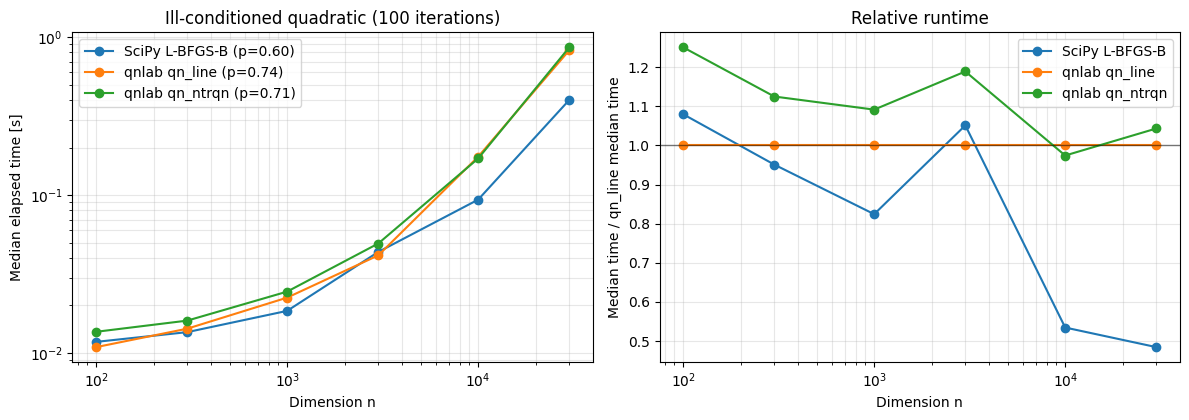

In [17]:
ill_quadratic_summary = summarize(ill_quadratic_results, "dimension")
reference_times = ill_quadratic_summary[
    ill_quadratic_summary["solver"] == "qnlab qn_line"
].set_index("dimension")["median_seconds"]
ill_quadratic_summary["ratio_to_qn_line"] = ill_quadratic_summary.apply(
    lambda row: row["median_seconds"] / reference_times.loc[row["dimension"]], axis=1
)

ill_quadratic_slopes = {}
ill_quadratic_large_n_slopes = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for solver, group in ill_quadratic_summary.groupby("solver"):
    slope = np.polyfit(np.log(group["dimension"]), np.log(group["median_seconds"]), 1)[
        0
    ]
    large_group = group[group["dimension"] >= 30_000]
    large_slope = np.polyfit(
        np.log(large_group["dimension"]), np.log(large_group["median_seconds"]), 1
    )[0]
    ill_quadratic_slopes[solver] = slope
    ill_quadratic_large_n_slopes[solver] = large_slope
    axes[0].loglog(
        group["dimension"],
        group["median_seconds"],
        "o-",
        label=f"{solver} (p={slope:.2f})",
    )
    axes[1].semilogx(group["dimension"], group["ratio_to_qn_line"], "o-", label=solver)
axes[0].set(
    xlabel="Dimension n",
    ylabel="Median elapsed time [s]",
    title=f"Ill-conditioned quadratic ({ILL_QUADRATIC_ITERATIONS} iterations)",
)
axes[1].axhline(1.0, color="black", linewidth=1, alpha=0.5)
axes[1].set(
    xlabel="Dimension n",
    ylabel="Median time / qn_line median time",
    title="Relative runtime",
)
for ax in axes:
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
fig.tight_layout()
display(ill_quadratic_summary)
display(
    pd.DataFrame(
        {
            "all_dimensions_slope": ill_quadratic_slopes,
            "n_at_least_30000_slope": ill_quadratic_large_n_slopes,
        }
    )
)

## Experiment 4: L-BFGS memory $m=3$ versus $m=10$

In [ ]:
MEMORY_VALUES = (3, 10)
MEMORY_COMPARISON_REPEATS = 5  # Use 3 for a quick run.
MEMORY_COMPARISON_DIMENSIONS = np.array([100, 300, 1000, 3000, 10000, 30000])
MEMORY_COMPARISON_ITERATIONS = 100

memory_cases = [
    (int(n), MEMORY_COMPARISON_ITERATIONS) for n in MEMORY_COMPARISON_DIMENSIONS
]
memory_results = pd.concat(
    [
        benchmark(
            memory_cases,
            repeats=MEMORY_COMPARISON_REPEATS,
            problem_factory=IllQuadraticProblem,
            memory=memory,
        ).assign(memory=memory)
        for memory in MEMORY_VALUES
    ],
    ignore_index=True,
)

repeat=1/5, n=100, k=100, m=3, SciPy L-BFGS-B: 0.012 s
repeat=1/5, n=100, k=100, m=3, qnlab qn_line: 0.007 s
repeat=1/5, n=100, k=100, m=3, qnlab qn_ntrqn: 0.009 s
repeat=1/5, n=300, k=100, m=3, SciPy L-BFGS-B: 0.006 s
repeat=1/5, n=300, k=100, m=3, qnlab qn_line: 0.007 s
repeat=1/5, n=300, k=100, m=3, qnlab qn_ntrqn: 0.008 s
repeat=1/5, n=1000, k=100, m=3, SciPy L-BFGS-B: 0.008 s
repeat=1/5, n=1000, k=100, m=3, qnlab qn_line: 0.013 s
repeat=1/5, n=1000, k=100, m=3, qnlab qn_ntrqn: 0.013 s
repeat=1/5, n=3000, k=100, m=3, SciPy L-BFGS-B: 0.028 s
repeat=1/5, n=3000, k=100, m=3, qnlab qn_line: 0.043 s
repeat=1/5, n=3000, k=100, m=3, qnlab qn_ntrqn: 0.035 s
repeat=1/5, n=10000, k=100, m=3, SciPy L-BFGS-B: 0.053 s
repeat=1/5, n=10000, k=100, m=3, qnlab qn_line: 0.037 s
repeat=1/5, n=10000, k=100, m=3, qnlab qn_ntrqn: 0.042 s
repeat=1/5, n=30000, k=100, m=3, SciPy L-BFGS-B: 0.175 s
repeat=1/5, n=30000, k=100, m=3, qnlab qn_line: 0.309 s
repeat=1/5, n=30000, k=100, m=3, qnlab qn_ntrqn: 0.401 

,solver,memory,dimension,median_seconds,min_seconds,max_seconds,median_function_calls,median_gradient_calls,median_objective
0,SciPy L-BFGS-B,3,100,0.006525,0.006132,0.015215,104.0,104.0,2.152823e-15
1,SciPy L-BFGS-B,3,300,0.006068,0.005476,0.012565,106.0,106.0,3.408461e-08
2,SciPy L-BFGS-B,3,1000,0.014471,0.008084,0.023345,110.0,110.0,2.761451e-03
3,SciPy L-BFGS-B,3,3000,0.021818,0.015209,0.030736,105.0,105.0,1.389670e-01
4,SciPy L-BFGS-B,3,10000,0.037354,0.033732,0.052671,106.0,106.0,1.494860e+00
5,SciPy L-BFGS-B,3,30000,0.200522,0.175274,0.216845,110.0,110.0,1.512192e+01
6,SciPy L-BFGS-B,10,100,0.011645,0.011164,0.014523,107.0,107.0,2.587600e-18
7,SciPy L-BFGS-B,10,300,0.015713,0.014377,0.017820,106.0,106.0,1.761041e-09
8,SciPy L-BFGS-B,10,1000,0.023057,0.020737,0.029807,106.0,106.0,8.188894e-04
9,SciPy L-BFGS-B,10,3000,0.036028,0.033213,0.044203,104.0,104.0,8.457010e-02


memory,solver,dimension,3,10,m3_over_m10
0,SciPy L-BFGS-B,100,0.006525,0.011645,0.560346
1,SciPy L-BFGS-B,300,0.006068,0.015713,0.386184
2,SciPy L-BFGS-B,1000,0.014471,0.023057,0.627625
3,SciPy L-BFGS-B,3000,0.021818,0.036028,0.605577
4,SciPy L-BFGS-B,10000,0.037354,0.085775,0.435495
5,SciPy L-BFGS-B,30000,0.200522,0.389657,0.514610
6,qnlab qn_line,100,0.007141,0.011441,0.624199
7,qnlab qn_line,300,0.007994,0.013491,0.592536
8,qnlab qn_line,1000,0.011256,0.028279,0.398038
9,qnlab qn_line,3000,0.028516,0.043027,0.662745


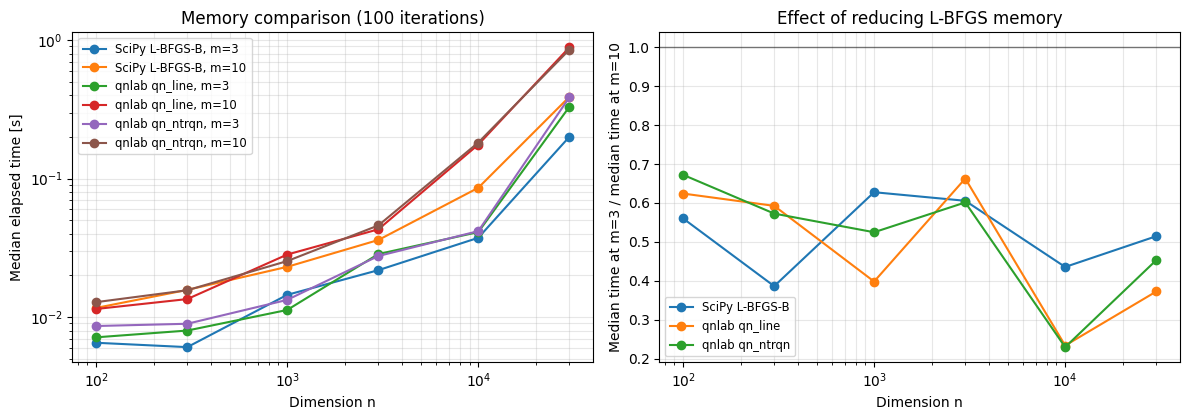

In [19]:
memory_summary = summarize(memory_results, "memory", "dimension")

memory_ratio = memory_summary.pivot(
    index=["solver", "dimension"], columns="memory", values="median_seconds"
).reset_index()
memory_ratio["m3_over_m10"] = memory_ratio[3] / memory_ratio[10]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for (solver, memory), group in memory_summary.groupby(["solver", "memory"]):
    axes[0].loglog(
        group["dimension"],
        group["median_seconds"],
        "o-",
        label=f"{solver}, m={memory}",
    )
for solver, group in memory_ratio.groupby("solver"):
    axes[1].semilogx(group["dimension"], group["m3_over_m10"], "o-", label=solver)
axes[0].set(
    xlabel="Dimension n",
    ylabel="Median elapsed time [s]",
    title=f"Memory comparison ({MEMORY_COMPARISON_ITERATIONS} iterations)",
)
axes[1].axhline(1.0, color="black", linewidth=1, alpha=0.5)
axes[1].set(
    xlabel="Dimension n",
    ylabel="Median time at m=3 / median time at m=10",
    title="Effect of reducing L-BFGS memory",
)
for ax in axes:
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize="small")
fig.tight_layout()
display(memory_summary)
display(memory_ratio)